In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/engineered_house_prices.csv")

print(df)


y = df['SalePrice']
x = df.drop(columns='SalePrice')


print(x)
print(y)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"Linear Regression R2 Score: {score}")

      Unnamed: 0  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
0              0          60         65.0     8450            7            5   
1              1          20         80.0     9600            6            8   
2              2          60         68.0    11250            7            5   
3              3          70         60.0     9550            7            5   
4              4          60         84.0    14260            8            5   
...          ...         ...          ...      ...          ...          ...   
1453        1455          60         62.0     7917            6            5   
1454        1456          20         85.0    13175            6            6   
1455        1457          70         66.0     9042            7            9   
1456        1458          20         68.0     9717            5            6   
1457        1459          20         75.0     9937            5            6   

      YearBuilt  YearRemodAdd  MasVnrAr

In [3]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)
ridge_score = r2_score(y_test, ridge_pred)
print(f'Ridge Regression R2 Score: {ridge_score}')

Ridge Regression R2 Score: 0.8943481111256452


In [4]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_score = r2_score(y_test, rf_pred)
print(f"Random Forest R2 Score: {rf_score}")



Random Forest R2 Score: 0.8892462617804915


In [6]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_score = r2_score(y_test, xgb_pred)
print(f'XGBoost R2 Score: {xgb_score}')

XGBoost R2 Score: 0.8829934965740358


In [7]:
import joblib

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns) 
top_10_features = importances.sort_values(ascending=False).head(10)

joblib.dump(ridge_model, '../models/ridge.pkl')
print("model successfully saved as 'ridge.pkl'!")

model successfully saved as 'ridge.pkl'!


In [8]:
import joblib
from sklearn.model_selection import cross_val_score

ridge_model = joblib.load('../models/ridge.pkl')


cv_scores = cross_val_score(ridge_model, x, y, cv=5, scoring='r2')

print(f"CV Scores: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.4f}")

CV Scores: [0.88230032 0.91234644 0.89956512 0.8983771  0.87778719]
Average CV Score: 0.8941


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    'alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]
}

grid_search = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

print("Running GridSearchCV for Ridge...")
grid_search.fit(X_train, y_train)

print("--- Grid Search Complete ---")
print(f"Best Settings Found: {grid_search.best_params_}")
print(f"Best R2 Score from Grid: {grid_search.best_score_:.4f}")

best_ridge = grid_search.best_estimator_

Running GridSearchCV for Ridge...
--- Grid Search Complete ---
Best Settings Found: {'alpha': 10.0}
Best R2 Score from Grid: 0.8966


In [19]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge_preds = best_ridge.predict(X_test)
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

comparison_table = pd.DataFrame({
    'Model': ['Tuned Ridge', 'Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, ridge_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ],
    'MAE ($)': [
        mean_absolute_error(y_test, ridge_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ],
    'MSE': [
        mean_squared_error(y_test, ridge_preds),
        mean_squared_error(y_test, rf_preds),
        mean_squared_error(y_test, xgb_preds)
    ],
    'RMSE ($)': [
        np.sqrt(mean_squared_error(y_test, ridge_preds)),
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_preds))
    ]
})

print("--- Final Model Comparison ---")
print(comparison_table.round(2))

--- Final Model Comparison ---
           Model  R2 Score   MAE ($)           MSE  RMSE ($)
0    Tuned Ridge      0.90  16751.96  5.338672e+08  23105.57
1  Random Forest      0.89  16521.11  6.117735e+08  24734.05
2        XGBoost      0.88  17489.01  6.463120e+08  25422.67


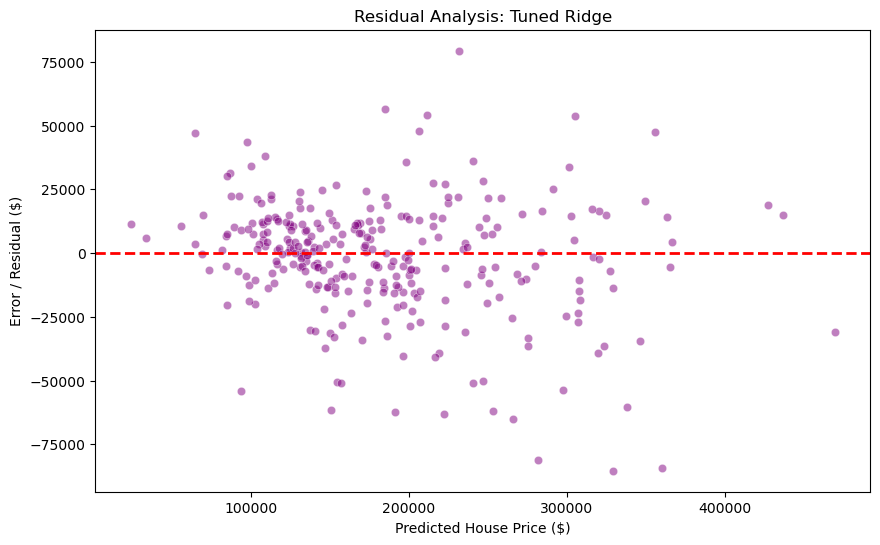

--- Top 10 Price Drivers (Ridge) ---
Neighborhood_StoneBr    21557.445868
RoofMatl_WdShngl        18921.341671
Neighborhood_NoRidge    15740.642663
KitchenQual_Ex          14567.919716
Neighborhood_Mitchel    12479.279536
BsmtExposure_Gd         11908.174978
Functional_Typ          11874.672701
LandSlope_Sev           11388.861413
SaleType_New            11281.251812
BsmtQual_Ex             10812.601716
dtype: float64




['../models/ridge.pkl']

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

residuals = y_test - ridge_preds

plt.figure(figsize=(10, 6))
sns.scatterplot(x=ridge_preds, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Analysis: Tuned Ridge')
plt.xlabel('Predicted House Price ($)')
plt.ylabel('Error / Residual ($)')
plt.show()

coefficients = pd.Series(best_ridge.coef_, index=X_train.columns)
top_10_features = coefficients.abs().sort_values(ascending=False).head(10)

print("--- Top 10 Price Drivers (Ridge) ---")
print(top_10_features)
print("\n")

joblib.dump(best_ridge, '../models/ridge.pkl')
